In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import seaborn as sns
import os

In [ ]:
import torch
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
from keras.layers import Dense
from keras.models import load_model
from keras.applications import ResNet50
from keras.applications.densenet import preprocess_input
from keras.metrics import binary_accuracy
from keras.preprocessing import image

In [ ]:
from keras.models import Model
from keras.optimizers import Adam, AdamW, Adamax
from keras.applications.resnet import ResNet50
from keras.layers import GlobalAveragePooling2D
from keras.models import Model
from keras import backend as K
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
from pathlib import Path

### Project Configuration

This cell defines a configuration class that stores important project parameters.

The configuration includes:

- List of disease classes
- Dataset paths
- Training parameters
- Model settings

This helps organize the code and makes it easier to manage training settings.

In [4]:
class CFG:
    CLASS_NAMES = [
        "Atelectasis",
        "Cardiomegaly",
        "Effusion",
        "Infiltration",
        "Mass",
        "Nodule",
        "Pneumonia",
        "Pneumothorax",
        "Consolidation",
        "Edema",
        "Emphysema",
        "Fibrosis",
        "Pleural_Thickening",
        "Hernia",
    ]
    BASE_PATH = Path("/ ")
    BASE_SPLIT_PATH = Path("/kaggle/input/datasetcsv")
    BEST_MODEL_PATH = "models/best_model.pt"
    ,,,,,,,,,,
    EPOCHS = 20
    EPOCHS_PER_START = 10
    START_EPOCH = 0
    
    BATCH_SIZE = 64
    DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    COLOR_MODE = 'rgb'
    TARGET_SIZE = (224, 224)
    INTERVAL = 10
    
    CHECKPOINT_PATH_VAL_LOSS = 'model/ResNet50_val_loss.keras'
    CHECKPOINT_PATH_VAL_AUC = 'model/ResNet50_val_AUC.keras'
    CHECKPOINT_PATH_TRAIN_LOSS = 'model/ResNet50_train_loss.keras'
    CHECKPOINT_PATH_TRAIN_AUC = 'model/ResNet50_train_AUC.keras'
    CHECKPOINT_PATH_TRAIN_ACCURACY = 'model/ResNet50_train_accuracy.keras'
    CHECKPOINT_PATH_VAL_ACCURACY = 'model/ResNet50_val_accuracy.keras'
    CHECKPOINT_DIR = os.path.dirname(CHECKPOINT_PATH_VAL_LOSS)

### Loading Dataset Splits

This cell loads the dataset split files using Pandas.

The dataset is divided into:

- **Training dataset**
- **Validation dataset**

Each CSV file contains image paths and corresponding disease labels.

In [5]:
train_df = pd.read_csv(f'{CFG.BASE_SPLIT_PATH}/train.csv')
val_df = pd.read_csv(f'{CFG.BASE_SPLIT_PATH}/validation.csv')
test_df = pd.read_csv(f'{CFG.BASE_SPLIT_PATH}//test.csv')
print('Train:', train_df.shape[0],'\nval:',val_df.shape[0], '\ntest:', test_df.shape[0])

Train: 79893 
val: 8654 
test: 23573


### Image Normalization Parameters

This cell defines mean and standard deviation values used to normalize the images.

These values come from the **ImageNet dataset**, which was used to pretrain the ResNet50 model.

Normalization helps stabilize training and improves model performance.

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
def preprocess_image(img):
    img = img / 255.0
    img = (img - mean) / std
    return img

### Creating Training Data Generator

This cell creates a data generator for the training dataset.

The generator performs:

- Image preprocessing
- Data augmentation
- Batch generation

Data augmentation techniques such as rotation and flipping help improve model generalization.

In [6]:
train_generator = ImageDataGenerator(
    samplewise_center=False, 
    samplewise_std_normalization=False, 
    horizontal_flip=True, 
    height_shift_range=0.1, 
    width_shift_range=0.05,
    rotation_range=5, 
    shear_range=0.1,
    zoom_range=0.05,    
    preprocessing_function=preprocess_image
).flow_from_dataframe(
    dataframe=train_df,
    directory=None,
    x_col='full_path',
    y_col=CFG.CLASS_NAMES,
    target_size=CFG.TARGET_SIZE,
    color_mode=CFG.COLOR_MODE,
    class_mode='raw',
    batch_size=CFG.BATCH_SIZE
)

Found 79893 validated image filenames.


### Creating Validation Data Generator

This cell creates the validation dataset generator.

Unlike training data, validation data only undergoes preprocessing and normalization.

No augmentation is applied so that evaluation remains unbiased.

In [7]:
val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_image
).flow_from_dataframe(
    dataframe=val_df,
    directory=None,
    x_col='full_path',
    y_col=CFG.CLASS_NAMES,
    target_size=CFG.TARGET_SIZE,
    color_mode=CFG.COLOR_MODE,
    class_mode='raw',
    batch_size=CFG.BATCH_SIZE
)

Found 8654 validated image filenames.


### Visualizing Training Images

This cell retrieves a batch of training images and displays them.

Visualization helps verify:

- Images are loaded correctly
- Labels correspond to the correct images

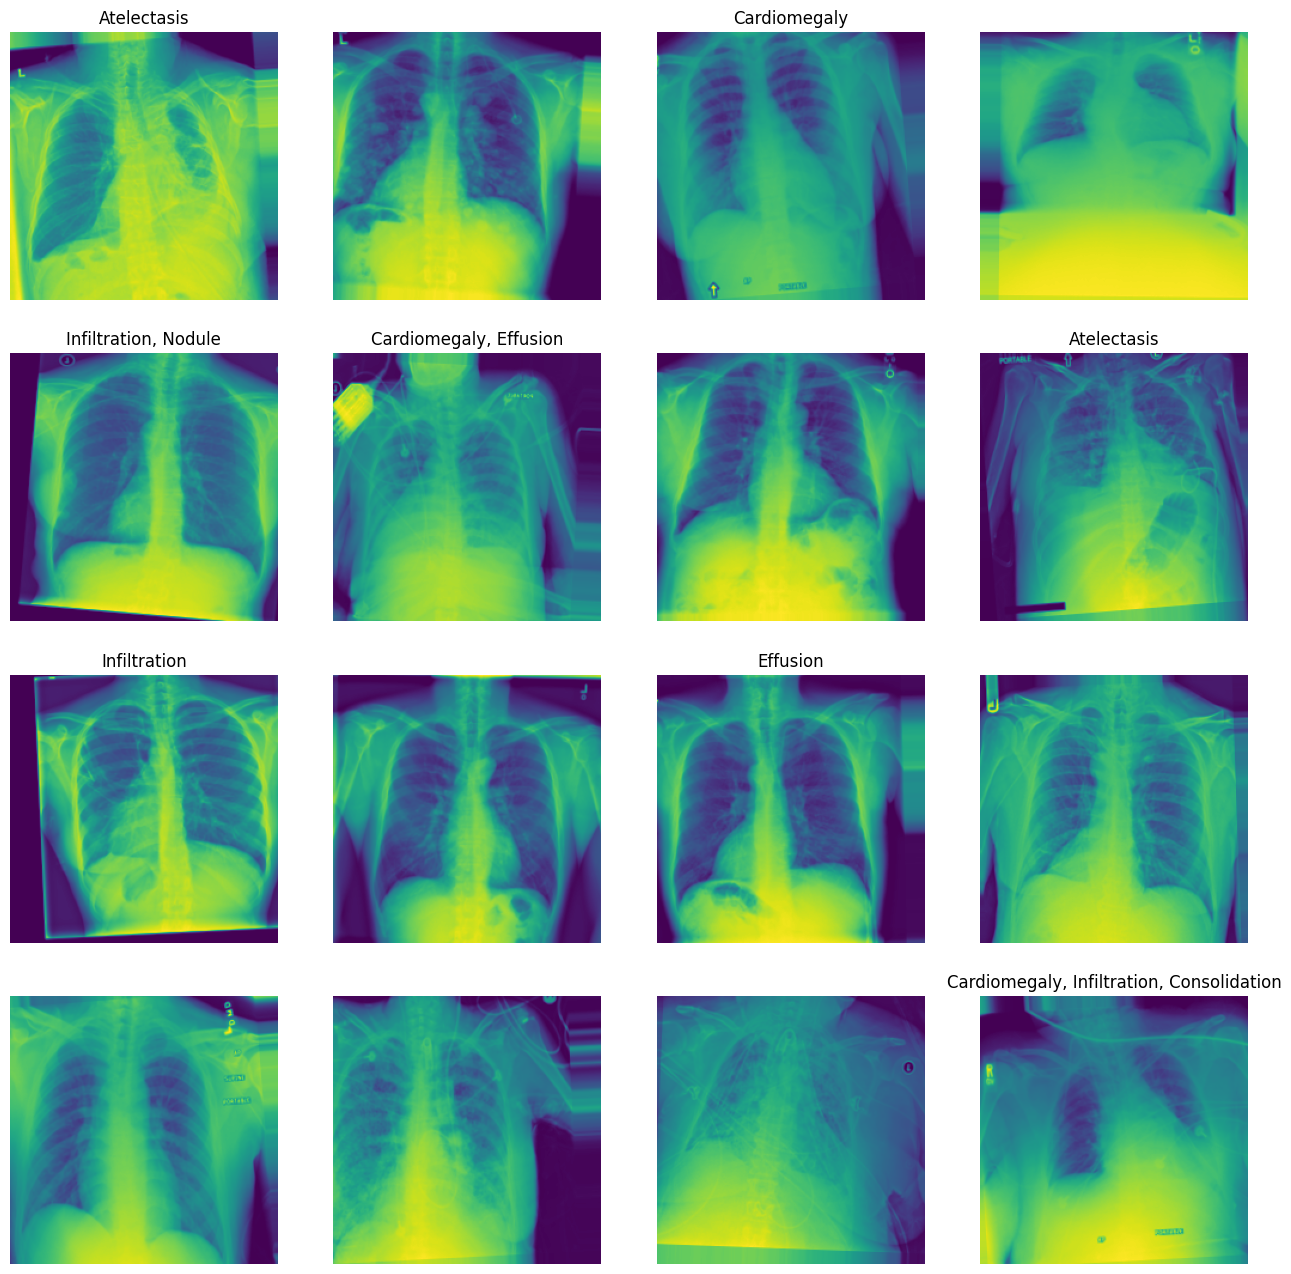

In [ ]:
images, labels_encoded = next(train_generator)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for image, label_encoded, ax in zip(images, labels_encoded, axes.flatten()):
    ax.imshow(image[:, :, 0])
    predicted_classes = [
        class_name for class_name, class_score in zip(CFG.CLASS_NAMES, label_encoded) 
        if class_score > 0.5
    ]
    ax.set_title(', '.join(predicted_classes))

    ax.axis('off')
plt.show()

### Building the Deep Learning Model

This cell defines the architecture of the neural network.

The model uses **ResNet50 pretrained on ImageNet** as the base model.

Additional classification layers are added to adapt the network for detecting chest diseases.

In [ ]:
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
    x = base_model.output
    preds = Dense(len(CFG.CLASS_NAMES), activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=preds)
    optimizer = Adamax(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['binary_accuracy', 'AUC'])
    model.summary()    
    return model


### Multi-GPU Training Strategy

This cell enables distributed training using TensorFlow's MirroredStrategy.

This allows the model to train on multiple GPUs simultaneously, which improves training speed and efficiency.

In [ ]:
strategy = tf.distribute.MirroredStrategy()
print('Number of devices (GPU): {}'.format(strategy.num_replicas_in_sync))

Number of devices (GPU): 2


### Training Callbacks for Fine-Tuning

This cell defines several **training callbacks** used to monitor the model’s performance during the fine-tuning stage and automatically save the best models.

**ModelCheckpoint**
These checkpoints save the model whenever performance improves based on specific metrics:

- **Validation Accuracy Checkpoint** – saves the model with the best validation accuracy.
- **Training Accuracy Checkpoint** – saves the model with the best binary accuracy during training.
- **Validation Loss Checkpoint** – saves the model when validation loss becomes the lowest.
- **Validation AUC Checkpoint** – saves the model with the highest validation AUC score.
- **Training AUC Checkpoint** – monitors AUC to track classification quality during training.
- **Training Loss Checkpoint** – saves the model when training loss reaches the minimum.

Saving models at different checkpoints allows comparison of models based on multiple performance metrics.

**ReduceLROnPlateau**
This callback reduces the **learning rate automatically when validation loss stops improving**. Lowering the learning rate helps the model fine-tune its weights more carefully and improves convergence.

**EarlyStopping**
Early stopping monitors **validation loss** and stops training if the model stops improving for several epochs. This prevents **overfitting** and saves computational time.

Together, these callbacks help ensure that the model training is **stable, efficient, and produces the best-performing model** during fine-tuning.

In [ ]:
#fine tuned
checkpoint_val_accuracy = ModelCheckpoint(CFG.CHECKPOINT_PATH_TRAIN_ACCURACY, 
                                          verbose=0, 
                                          monitor='val_accuracy', 
                                          save_best_only=True, 
                                          mode='max')

checkpoint_train_accuracy = ModelCheckpoint(CFG.CHECKPOINT_PATH_VAL_ACCURACY, 
                                            verbose=0, 
                                            monitor='val_binary_accuracy', 
                                            save_best_only=True, 
                                            mode='max')

checkpoint_val_loss = ModelCheckpoint(CFG.CHECKPOINT_PATH_VAL_LOSS, 
                                      verbose=0, 
                                      save_best_only=True)

checkpoint_val_AUC = ModelCheckpoint(CFG.CHECKPOINT_PATH_VAL_AUC, 
                                      verbose=0, 
                                      save_best_only=True, 
                                      monitor='val_AUC', 
                                      mode='max')

checkpoint_train_AUC = ModelCheckpoint(CFG.CHECKPOINT_PATH_TRAIN_AUC, 
                                        verbose=0, 
                                        save_best_only=True, 
                                        monitor='val_AUC', 
                                        mode='max')

checkpoint_train_loss = ModelCheckpoint(CFG.CHECKPOINT_PATH_TRAIN_LOSS, 
                                        verbose=0, 
                                        monitor='loss', 
                                        mode='min', 
                                        save_best_only=True)

anne = ReduceLROnPlateau(monitor='val_loss', 
                         factor=0.1, 
                         patience=2, 
                         verbose=1, 
                         min_lr=1e-7)

early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               verbose=1, 
                               mode='min')


### Load or Train Model Function

This function checks whether a **previously trained model already exists**.  
If the model file is found, it **loads the saved model** instead of training again.  
If the model file does not exist, it **builds a new model and starts training from scratch**.

The function uses the starting epoch from the configuration (`CFG.START_EPOCH`) to determine which saved model file to look for. This approach helps **save time and computational resources**, since training deep learning models can be expensive.

In summary, this function ensures that the workflow can **resume training from a saved checkpoint or initialize a new model if no checkpoint is available**.

In [13]:
def load_or_train_model(start_epoch = CFG.START_EPOCH):
    model_path = f'/kaggle/input/resnet50{start_epoch}epochs/ResNet50_epoch_{start_epoch}.keras'
    if os.path.exists(model_path):
        print(f'Loading model from {model_path}')
        multi_gpu_model = tf.keras.models.load_model(model_path)
    else:
        print(f'Model not found. Training from scratch.')
        multi_gpu_model = build_model()
    return multi_gpu_model

### Initializing Model with Distributed Training Strategy

This cell loads or builds the model within the **TensorFlow distribution strategy scope**.

`strategy.scope()` ensures that the model is created under the **multi-GPU training environment**, allowing TensorFlow to distribute computations across multiple GPUs automatically.

Inside this scope, the `load_or_train_model()` function is called to either **load an existing trained model or create a new one**, and the resulting model is assigned to `multi_gpu_model` for further training or evaluation.

In [14]:
with strategy.scope():
    multi_gpu_model = load_or_train_model()

Model not found. Training from scratch.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 23,563,278 (89.89 MB)

 Non-trainable params: 53,120 (207.50 KB)

### Training History Visualization

This function is used to **visualize the model's training performance over epochs**.

It plots two important metrics:

- **Loss Plot** – shows how the training loss and validation loss change over epochs. This helps determine whether the model is learning properly or overfitting.
- **AUC Plot** – shows the training AUC and validation AUC across epochs. AUC measures how well the model distinguishes between different disease classes.

The function also saves the generated plots as an image file for later reference. This visualization helps analyze the **learning progress and performance of the model during training**.

In [17]:
def plot_history(history, epoch_start, epoch_end):
    plt.figure(figsize=(12, 4))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss from epoch {epoch_start} to {epoch_end}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # AUC
    plt.subplot(1, 2, 2)
    plt.plot(history.history['AUC'], label='Train AUC')
    plt.plot(history.history['val_AUC'], label='Validation AUC')
    plt.title(f'AUC from epoch {epoch_start} to {epoch_end}')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.savefig(f'training_history_{epoch_start}_to_{epoch_end}.png')
    plt.show()

### Model Training Loop with Checkpoints

This cell runs the **training process of the model in stages**.

The loop trains the model from the starting epoch up to the total number of epochs, progressing in small segments defined by `CFG.EPOCHS_PER_START`. This allows the training to be **controlled and monitored step-by-step**.

During training:
- The model learns from the **training dataset** using `train_generator`.
- Performance is evaluated on the **validation dataset** using `val_generator`.
- Several **callbacks** are used to monitor metrics like loss, accuracy, and AUC, and to automatically save the best-performing models.

After each training segment:
- The model is **saved with the current epoch number**.
- The **training history is plotted** to visualize loss and AUC trends.

This approach helps in **tracking model performance, saving checkpoints, and analyzing training progress effectively**.

Training from epoch 1 to 10
Epoch 1/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1983s 1s/step - AUC: 0.7933 - binary_accuracy: 0.9459 - loss: 0.1751 - val_AUC: 0.8167 - val_binary_accuracy: 0.9469 - val_loss: 0.1692 - learning_rate: 0.0010
Epoch 2/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1459s 1s/step - AUC: 0.8408 - binary_accuracy: 0.9486 - loss: 0.1605 - val_AUC: 0.8148 - val_binary_accuracy: 0.9484 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 3/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1473s 1s/step - AUC: 0.8495 - binary_accuracy: 0.9490 - loss: 0.1568 - val_AUC: 0.8427 - val_binary_accuracy: 0.9493 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 4/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1511s 1s/step - AUC: 0.8580 - binary_accuracy: 0.9491 - loss: 0.1540 - val_AUC: 0.8577 - val_binary_accuracy: 0.9496 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 5/10
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1415s 1s/step - AUC: 0.8618 - binary_accuracy: 0.9497 - loss: 0.1521 - val_AUC: 0.8514 - val_binary_accuracy: 0.9498 - val

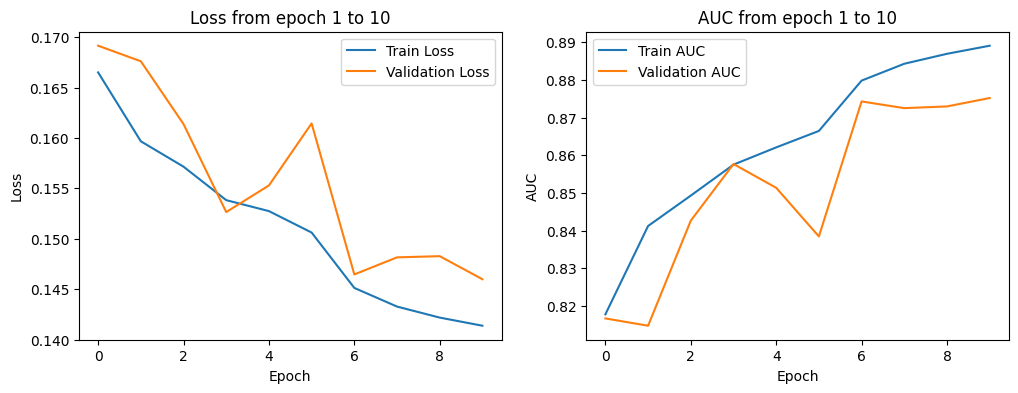

Training from epoch 11 to 20
Epoch 11/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1443s 1s/step - AUC: 0.8897 - binary_accuracy: 0.9505 - loss: 0.1418 - val_AUC: 0.8802 - val_binary_accuracy: 0.9502 - val_loss: 0.1460 - learning_rate: 1.0000e-05
Epoch 12/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1397s 1s/step - AUC: 0.8898 - binary_accuracy: 0.9510 - loss: 0.1409 - val_AUC: 0.8761 - val_binary_accuracy: 0.9509 - val_loss: 0.1463 - learning_rate: 1.0000e-05
Epoch 13/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1458s 1s/step - AUC: 0.8880 - binary_accuracy: 0.9506 - loss: 0.1420 - val_AUC: 0.8818 - val_binary_accuracy: 0.9505 - val_loss: 0.1438 - learning_rate: 1.0000e-05
Epoch 14/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 1437s 1s/step - AUC: 0.8891 - binary_accuracy: 0.9507 - loss: 0.1411 - val_AUC: 0.8857 - val_binary_accuracy: 0.9503 - val_loss: 0.1438 - learning_rate: 1.0000e-05
Epoch 15/20
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - AUC: 0.8908 - binary_accuracy: 0.9511 - loss: 0.1402
Epoch 15: ReduceLROnPlateau reduci

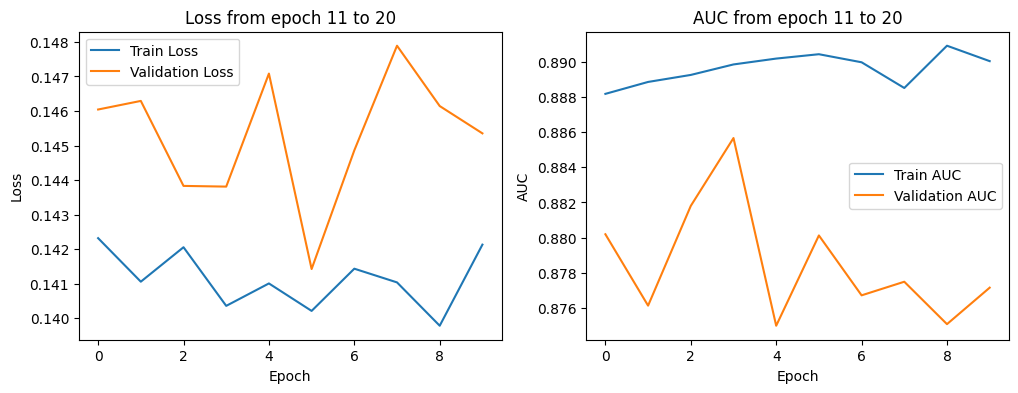

In [ ]:
for i in range(CFG.START_EPOCH, CFG.EPOCHS, CFG.EPOCHS_PER_START):
    end_epoch = min(i + CFG.EPOCHS_PER_START, CFG.EPOCHS)
    
    print(f'Training from epoch {i+1} to {end_epoch}')
    history = multi_gpu_model.fit(
        train_generator,
        epochs=end_epoch,
        initial_epoch=i,
        callbacks=[anne,
                   checkpoint_val_loss, checkpoint_val_AUC,
                   checkpoint_train_loss, checkpoint_train_AUC,
                   checkpoint_val_accuracy, checkpoint_train_accuracy],
        validation_data=val_generator,
    )

    
    model_path = f'ResNet50_epoch_{end_epoch}.keras'
    multi_gpu_model.save(model_path)
    print(f'Model saved after epoch {end_epoch} at {model_path}')

    plot_history(history, i+1, end_epoch)

### Loading a Pretrained Model

This cell loads a previously trained **ResNet50 model** from a saved `.keras` file using TensorFlow's `load_model()` function.

The saved model contains both the **model architecture and the learned weights** from training. By loading this file, the model can be **directly used for evaluation or prediction** without retraining.

In this case, the model that was trained for **20 epochs** is being loaded from the Kaggle input directory.

In [7]:
load_model = tf.keras.models.load_model("/kaggle/input/resnet20epochs/ResNet50_epoch_20.keras")

### Creating Test Data Generator

This cell prepares the **test dataset generator** used to evaluate the trained model.

`ImageDataGenerator` is used to load and preprocess the test images using the same **preprocessing function** applied during training. The `flow_from_dataframe()` method reads image paths and labels directly from the **test dataframe (`test_df`)**.

Key points:
- **Images are resized** according to `CFG.TARGET_SIZE`.
- **Labels correspond to the 14 disease classes** defined in `CFG.CLASS_NAMES`.
- **class_mode='raw'** is used because this is a **multi-label classification problem**.
- **shuffle=False** ensures the order of images remains the same, which is important when comparing predictions with true labels during evaluation.

The generator loads images in **batches**, making it efficient to process large datasets during testing.

In [ ]:

batch_size = 512
test_generator = ImageDataGenerator(
    preprocessing_function=preprocess_image
).flow_from_dataframe(
    dataframe=test_df,
    directory=None,
    x_col='full_path',
    y_col=CFG.CLASS_NAMES,
    target_size=CFG.TARGET_SIZE,
    color_mode=CFG.COLOR_MODE,
    class_mode='raw',
    batch_size=CFG.BATCH_SIZE,
    shuffle=False 
)

Found 23573 validated image filenames.


### ROC-AUC Evaluation Function

This function evaluates the trained model using the **ROC-AUC metric for each disease class**.

First, the function loops through the **test dataset generator** and collects:
- **Predicted probabilities** from the model
- **True labels** from the dataset

These predictions and labels are then combined into complete arrays for evaluation.

For each disease class, the **ROC-AUC score** is calculated using `roc_auc_score()`. This metric measures how well the model can **distinguish between positive and negative cases** for each disease.

Finally, the function:
- Prints the **ROC-AUC score for every disease class**
- Calculates and prints the **average ROC-AUC score across all classes**, which gives an overall measure of the model’s classification performance.

In [ ]:
def ROC_AUC (model):
    y_preds = []
    y_trues = []
    for _ in range(len(test_generator)):
        x_batch, y_batch = next(test_generator)
        y_pred_batch = model.predict(x_batch, verbose=0)
        y_preds.append(y_pred_batch)
        y_trues.append(y_batch)
    y_preds = np.concatenate(y_preds, axis=0)
    y_trues = np.concatenate(y_trues, axis=0)
    class_labels = test_df[CFG.CLASS_NAMES].columns

    roc_auc_scores = {}
    for i, label in enumerate(class_labels):
        auc = roc_auc_score(y_trues[:, i], y_preds[:, i])
        roc_auc_scores[label] = auc

    for label, auc in roc_auc_scores.items():
        print(f"ROC AUC Score for {label}: {auc:.4f}")
    average_roc_auc = np.mean(list(roc_auc_scores.values()))
    print(f"Average ROC AUC Score: {average_roc_auc:.4f}")

In [10]:
ROC_AUC(load_model)

ROC AUC Score for Atelectasis: 0.8137
ROC AUC Score for Cardiomegaly: 0.9047
ROC AUC Score for Effusion: 0.8848
ROC AUC Score for Infiltration: 0.7099
ROC AUC Score for Mass: 0.8517
ROC AUC Score for Nodule: 0.7620
ROC AUC Score for Pneumonia: 0.7552
ROC AUC Score for Pneumothorax: 0.8804
ROC AUC Score for Consolidation: 0.8051
ROC AUC Score for Edema: 0.8892
ROC AUC Score for Emphysema: 0.9058
ROC AUC Score for Fibrosis: 0.8181
ROC AUC Score for Pleural_Thickening: 0.7855
ROC AUC Score for Hernia: 0.9380
Average ROC AUC Score: 0.8360


### Evaluating Multiple Saved Models

This cell evaluates several saved versions of the ResNet50 model and compares their performance.

The `evaluate_model()` function loads each model from the given file paths and calculates its **ROC-AUC score** using the previously defined `ROC_AUC()` function. Each model was saved based on different training checkpoints such as **training loss, training AUC, validation loss, and validation AUC**.

The function:
- Loads each saved model.
- Runs evaluation on the **test dataset**.
- Computes the **ROC-AUC score** for the model.
- Stores the results in a dictionary for comparison.

This allows us to **compare different checkpoint models and identify which saved version performs the best on the test data**.

In [11]:
from keras.models import load_model

def evaluate_model(paths):
    results = {}
    
    for name, path in paths.items():
        model = load_model(path)
        auc = ROC_AUC(model)
        results[name] = auc
        print(f"{name} = {auc}")
    
    return results

# Define the paths for each model
model_paths = {
    "model_train_loss": '/kaggle/input/resnet20epochs/model/ResNet50_train_loss.keras',
    "model_train_AUC": '/kaggle/input/resnet20epochs/model/ResNet50_train_AUC.keras',
    "model_val_loss": '/kaggle/input/resnet20epochs/model/ResNet50_val_loss.keras',
    "model_val_AUC": '/kaggle/input/resnet20epochs/model/ResNet50_val_AUC.keras',
}
results = evaluate_model(model_paths)


ROC AUC Score for Atelectasis: 0.8138
ROC AUC Score for Cardiomegaly: 0.9047
ROC AUC Score for Effusion: 0.8848
ROC AUC Score for Infiltration: 0.7099
ROC AUC Score for Mass: 0.8517
ROC AUC Score for Nodule: 0.7618
ROC AUC Score for Pneumonia: 0.7551
ROC AUC Score for Pneumothorax: 0.8803
ROC AUC Score for Consolidation: 0.8051
ROC AUC Score for Edema: 0.8893
ROC AUC Score for Emphysema: 0.9059
ROC AUC Score for Fibrosis: 0.8181
ROC AUC Score for Pleural_Thickening: 0.7857
ROC AUC Score for Hernia: 0.9378
Average ROC AUC Score: 0.8360
model_train_loss = None
ROC AUC Score for Atelectasis: 0.8135
ROC AUC Score for Cardiomegaly: 0.9043
ROC AUC Score for Effusion: 0.8849
ROC AUC Score for Infiltration: 0.7099
ROC AUC Score for Mass: 0.8515
ROC AUC Score for Nodule: 0.7610
ROC AUC Score for Pneumonia: 0.7543
ROC AUC Score for Pneumothorax: 0.8796
ROC AUC Score for Consolidation: 0.8048
ROC AUC Score for Edema: 0.8883
ROC AUC Score for Emphysema: 0.9049
ROC AUC Score for Fibrosis: 0.8187
RO

In [12]:
model_val_AUC = load_model('/kaggle/input/resnet20epochs/model/ResNet50_val_AUC.keras')

In [ ]:
y_preds = []
y_trues = []

In [ ]:
for _ in range(len(test_generator)):
    x_batch, y_batch = next(test_generator)
    y_pred_batch = model_val_AUC.predict(x_batch, verbose =0)
    y_preds.append(y_pred_batch)
    y_trues.append(y_batch)

In [ ]:
y_preds = np.vstack(y_preds)  
y_trues = np.vstack(y_trues) 

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_scores = {}
for i, label in enumerate(CFG.CLASS_NAMES):
    auc = roc_auc_score(y_trues[:, i], y_preds[:, i])
    roc_auc_scores[label] = auc
for label, auc in roc_auc_scores.items():
    print(f"ROC AUC Score for {label}: {auc:.4f}")
average_roc_auc = np.mean(list(roc_auc_scores.values()))
print(f"Average ROC AUC Score: {average_roc_auc:.4f}")

ROC AUC Score for Atelectasis: 0.8135
ROC AUC Score for Cardiomegaly: 0.9043
ROC AUC Score for Effusion: 0.8849
ROC AUC Score for Infiltration: 0.7099
ROC AUC Score for Mass: 0.8515
ROC AUC Score for Nodule: 0.7610
ROC AUC Score for Pneumonia: 0.7543
ROC AUC Score for Pneumothorax: 0.8796
ROC AUC Score for Consolidation: 0.8048
ROC AUC Score for Edema: 0.8883
ROC AUC Score for Emphysema: 0.9049
ROC AUC Score for Fibrosis: 0.8187
ROC AUC Score for Pleural_Thickening: 0.7855
ROC AUC Score for Hernia: 0.9370
Average ROC AUC Score: 0.8356


Micro-Average ROC AUC Score: 0.8811


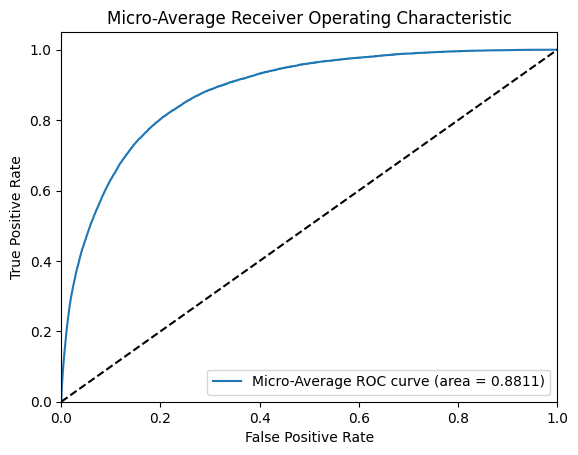

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

roc_auc_micro = roc_auc_score(y_trues, y_preds, average='micro')
print(f"Micro-Average ROC AUC Score: {roc_auc_micro:.4f}")

fpr, tpr, _ = roc_curve(y_trues.ravel(), y_preds.ravel())


plt.figure()
plt.plot(fpr, tpr, label=f'Micro-Average ROC curve (area = {roc_auc_micro:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-Average Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('Micro-Average-ROC.png', bbox_inches='tight')

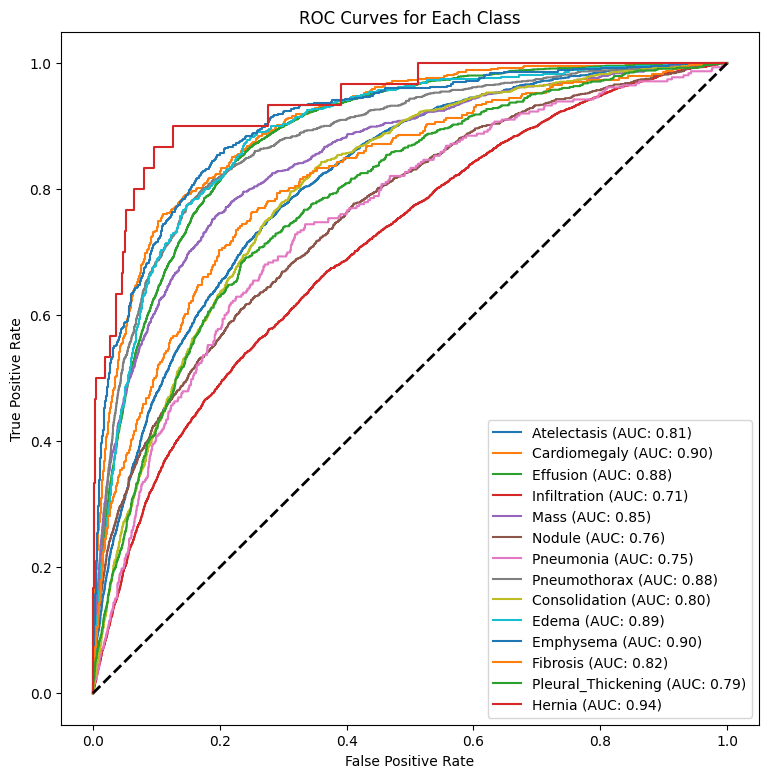

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, c_ax = plt.subplots(1, 1, figsize=(9, 9))
for (idx, c_label) in enumerate(CFG.CLASS_NAMES):
    fpr, tpr, thresholds = roc_curve(y_trues[:, idx], y_preds[:, idx])
    auc_score = auc(fpr, tpr)
    c_ax.plot(fpr, tpr, label=f'{c_label} (AUC: {auc_score:.2f})')

c_ax.plot([0, 1], [0, 1], 'k--', lw=2)
c_ax.set_xlabel('False Positive Rate')
c_ax.set_ylabel('True Positive Rate')
c_ax.set_title('ROC Curves for Each Class')
c_ax.legend(loc='best')
fig.savefig('ROC Curves.png')
plt.show()

<Figure size 3000x2800 with 0 Axes>

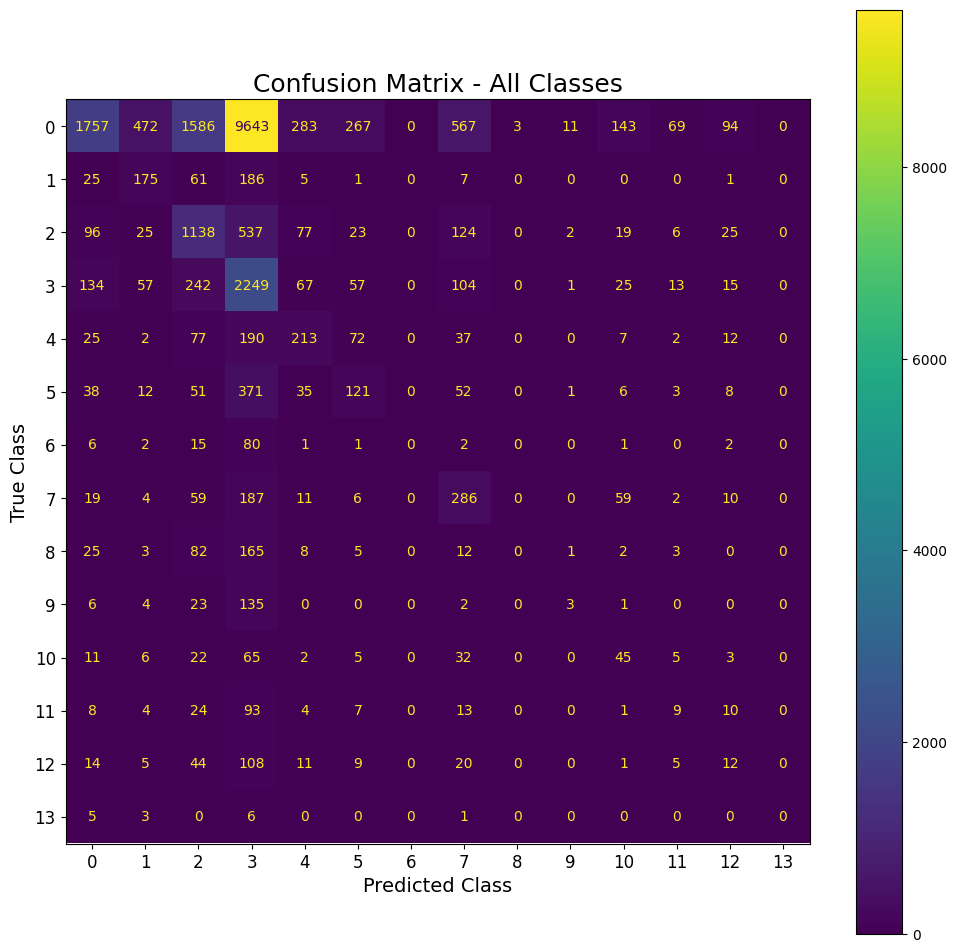

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_true_single = np.argmax(y_trues, axis=1)
y_pred_single = np.argmax(y_preds, axis=1)

cm = confusion_matrix(y_true_single, y_pred_single)

plt.figure(figsize=(30, 28))  

disp = ConfusionMatrixDisplay(confusion_matrix=cm, )
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(cmap='viridis', values_format='d', ax=ax, )  
plt.title('Confusion Matrix - All Classes', fontsize=18)  
plt.xlabel('Predicted Class', fontsize=14) 
plt.ylabel('True Class', fontsize=14) 
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12) 
plt.savefig('unified_confusion_matrix_large_cells.png', bbox_inches='tight')
plt.show()


In [24]:
avg_precision = np.mean(list(precision_scores.values()))
avg_recall = np.mean(list(recall_scores.values()))
avg_f1 = np.mean(list(f1_scores.values()))
avg_accuracy = np.mean(list(accuracy_scores.values()))

print(f"\nAverage Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1 Score: {avg_f1:.4f}")
print(f"Average Accuracy: {avg_accuracy:.4f}")


Average Precision: 0.3764
Average Recall: 0.0905
Average F1 Score: 0.1316
Average Accuracy: 0.9489
